<a href="https://colab.research.google.com/github/deaconkoh/API-Data-Pipeline/blob/main/SOH_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HUST Battery Dataset
- It consists of **77 lithium-ion battery cells**.  
- The **nominal capacity** is about **1.1 Ah**, and the **nominal voltage** is approximately **3.3 V**.  
- All cells were cycled at a constant temperature of **30 °C** (ambient / test temperature).  
- In total, the dataset includes over **146,000 charge–discharge cycles** across all cells (many cycles per battery).  


In [ ]:
import pickle
import pandas as pd
import os
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Inspect dataset

In [ ]:
folder_path = "/content/gdrive/MyDrive/HUST Battery Dataset"
files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".pkl")]
print("Number of files:", len(files))
print("First file:", files[:1])

sample_file = files[0]
with open(sample_file, "rb") as f:
    data = pickle.load(f)

print("Type of object:", type(data))

# check dict keys
if isinstance(data, dict):
    print("Keys:", data.keys())
elif isinstance(data, list):
    print("Length of list:", len(data))
    print("Type of first element:", type(data[0]))

Number of files: 77
First file: ['/content/gdrive/MyDrive/HUST Battery Dataset/HUST_1-1.pkl']
Type of object: <class 'dict'>
Keys: dict_keys(['cell_id', 'cycle_data', 'form_factor', 'anode_material', 'cathode_material', 'electrolyte_material', 'nominal_capacity_in_Ah', 'depth_of_charge', 'depth_of_discharge', 'already_spent_cycles', 'max_voltage_limit_in_V', 'min_voltage_limit_in_V', 'max_current_limit_in_A', 'min_current_limit_in_A', 'reference', 'description', 'charge_protocol', 'discharge_protocol'])


In [ ]:
# Inspect the first cycle dictionary
cd = data["cycle_data"]
first_cycle = cd[0]
print("Keys in first cycle:", first_cycle.keys())

for k, v in first_cycle.items():
    if isinstance(v, (int, float, str)):
        print(f"{k}: {v}")
    elif isinstance(v, list):
        print(f"{k}: list of length {len(v)} (first 5: {v[:5]})")
    elif isinstance(v, dict):
        print(f"{k}: dict with keys {list(v.keys())[:10]}")


Keys in first cycle: dict_keys(['cycle_number', 'current_in_A', 'voltage_in_V', 'charge_capacity_in_Ah', 'discharge_capacity_in_Ah', 'time_in_s', 'temperature_in_C', 'internal_resistance_in_ohm'])
cycle_number: 1
current_in_A: list of length 836 (first 5: [5.49813, 5.4985100000000005, 5.4985100000000005, 5.4985100000000005, 5.49813])
voltage_in_V: list of length 836 (first 5: [2.7731, 2.9811, 3.0912, 3.1606, 3.2118])
charge_capacity_in_Ah: list of length 836 (first 5: [0.0, 0.006109455555555556, 0.013746275000000002, 0.02138309444444445, 0.029019386111111115])
discharge_capacity_in_Ah: list of length 836 (first 5: [0.0, 0.0, 0.0, 0.0, 0.0])
time_in_s: list of length 836 (first 5: [0, 4, 9, 14, 19])


## Objective: Extract State of Health (SOH)

SOH is a derived metric and is usually defined as:  

$$
\text{SOH(cycle)} = \frac{\text{Discharge Capacity at this cycle}}{\text{Reference Capacity}}
$$

---

#### Discharge Capacity
- The amount of charge the battery delivers during the discharge phase of a cycle.  
<sub><i>This value can be found inside the `cycle_data` field of the dataset.</i></sub>  

#### Reference Capacity
- This is the fixed baseline against which each cycle’s discharge capacity is compared.  
- Two common choices:  
  1. **Nominal capacity** (what the manufacturer claims) — given directly in the metadata under the key `nominal_capacity_in_Ah` (≈ 1.1 Ah for HUST cells).  
  2. **Initial measured capacity** (what your battery actually delivered in the first few cycles) — calculated as the maximum discharge capacity observed in the first few cycles (from `cycle_data`).  


In [ ]:
"""
Extract per-cycle discharge capacity (Qd) from HUST data
"""
cd = data["cycle_data"]
rows = []
for rec in cd:
    cyc = rec.get("cycle_number")
    qd_series = rec.get("discharge_capacity_in_Ah")
    if qd_series is None:
        qd = np.nan
    else:
        # per cycle discharge capacity = max cumulative discharge capacity within the cycle
        qd = float(np.nanmax(qd_series)) if len(qd_series) else np.nan
    rows.append({"cycle_number": cyc, "Qd_Ah": qd})

df_cycles = pd.DataFrame(rows).sort_values("cycle_number").reset_index(drop=True)
df_cycles.head()

,cycle_number,Qd_Ah
0,1,1.188047
1,2,1.186868
2,3,1.186568
3,4,1.185645
4,5,1.185051


In [ ]:
"""
Get SOH values for each cycle
"""
ref_capacity_nominal = data.get("nominal_capacity_in_Ah", 1.1)
df_cycles["SOH_nominal"] = df_cycles["Qd_Ah"] / ref_capacity_nominal

ref_capacity_measured = df_cycles.loc[:5, "Qd_Ah"].max()
df_cycles["SOH_initial"] = df_cycles["Qd_Ah"] / ref_capacity_measured

df_cycles.head()


,cycle_number,Qd_Ah,SOH_nominal,SOH_initial
0,1,1.188047,1.080043,1.000000
1,2,1.186868,1.078971,0.999007
2,3,1.186568,1.078698,0.998755
3,4,1.185645,1.077859,0.997978
4,5,1.185051,1.077319,0.997478


### `cycle_discharge_Ah(qd_series)`
This function calculates the **per-cycle discharge capacity (`Qd_Ah`)** from a list or array of cumulative discharge values recorded during one battery cycle.

- It takes a list or array called `qd_series`, which represents the **cumulative discharge capacity (in Ah)** measured over time during a single cycle.
- Then it returns the **difference between the maximum and minimum values** in that list:

$$
\text{Qd_Ah} = \max(\text{series}) - \min(\text{series})
$$


This value (`Qd_Ah`) represents the **total charge delivered in that discharge cycle**.


In [ ]:
def cycle_discharge_Ah(qd_series):
    if qd_series is None or len(qd_series) == 0:
        return np.nan
    arr = np.array(qd_series, dtype=float)
    val = float(np.nanmax(arr) - np.nanmin(arr))
    # Guard against negative or absurd values
    return np.nan if (val < 0) else val

test_series_1 = [0.0, 0.2, 0.5, 0.9, 1.1]
test_series_2 = [0.5, 0.6, 0.6, 0.6, 0.6]
test_series_3 = [0.9, 0.4, 0.1, 0.0]
test_series_4 = []
test_series_5 = [np.nan, np.nan, 0.8, 1.1, np.nan]

print("Test 1 (normal):", cycle_discharge_Ah(test_series_1))
print("Test 2 (flat):", cycle_discharge_Ah(test_series_2))
print("Test 3 (decreasing):", cycle_discharge_Ah(test_series_3))
print("Test 4 (empty):", cycle_discharge_Ah(test_series_4))
print("Test 5 (with NaNs):", cycle_discharge_Ah(test_series_5))


Test 1 (normal): 1.1
Test 2 (flat): 0.09999999999999998
Test 3 (decreasing): 0.9
Test 4 (empty): nan
Test 5 (with NaNs): 0.30000000000000004


In [ ]:
def extract_qd_raw(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    rows = []
    for rec in data["cycle_data"]:
        cyc = rec.get("cycle_number")
        qd = cycle_discharge_Ah(rec.get("discharge_capacity_in_Ah"))
        rows.append({"cycle_number": cyc, "Qd_Ah": qd})
    df = pd.DataFrame(rows).sort_values("cycle_number").reset_index(drop=True)
    df["cell_file"] = os.path.basename(file_path)
    df["ref_nominal_Ah"] = float(data.get("nominal_capacity_in_Ah", 1.1))
    return df

# Build RAW table (no filtering yet)
df_raw_list = []
for fp in files:
    try:
        df_raw_list.append(extract_qd_raw(fp))
    except Exception as e:
        print("Error in", fp, "->", e)

df_raw = pd.concat(df_raw_list, ignore_index=True)

In [ ]:
# Global view
print(df_raw["Qd_Ah"].describe(percentiles=[.001,.005,.01,.99,.995,.999]).round(3))

# Per-file quick tails
perfile = (
    df_raw.groupby("cell_file")["Qd_Ah"]
    .describe(percentiles=[.01,.99])
    [["min","1%","mean","99%","max","count"]]
    .round(3)
)
print(perfile.head(10))


count    146120.000
mean          1.101
std           0.105
min           0.891
0.1%          0.897
0.5%          0.901
1%            0.904
50%           1.126
99%           1.221
99.5%         1.226
99.9%         1.237
max          23.753
Name: Qd_Ah, dtype: float64
                 min     1%   mean    99%     max   count
cell_file                                                
HUST_1-1.pkl   0.894  0.900  1.087  1.183   1.188  1504.0
HUST_1-2.pkl   0.895  0.900  1.093  1.212   1.221  2678.0
HUST_1-3.pkl   0.897  0.903  1.098  1.204   1.205  1858.0
HUST_1-4.pkl   0.899  0.904  1.101  1.205   1.206  1500.0
HUST_1-5.pkl   0.900  0.906  1.081  1.200   1.202  1971.0
HUST_1-6.pkl   0.896  0.900  1.087  1.209   1.219  1143.0
HUST_1-7.pkl   0.897  0.903  1.096  1.197   1.203  1678.0
HUST_1-8.pkl   0.898  0.904  1.103  1.202  23.753  2285.0
HUST_10-1.pkl  0.900  0.906  1.095  1.189   1.195  1702.0
HUST_10-2.pkl  0.901  0.909  1.112  1.222   1.223  1697.0


In [ ]:
# Identify problematic cells (those with extreme max Qd_Ah)
bad_cells = perfile[perfile["max"] > 2.0].index.tolist()
print("Cells with suspiciously high discharge capacity:", bad_cells)

# Inspect the first few raw cycles for one of them (e.g. HUST_1-8.pkl)
target = "HUST_1-8.pkl"
df_inspect = df_raw[(df_raw["cell_file"] == target) & (df_raw["Qd_Ah"] > 2)]
print(df_inspect)
print(perfile.sort_values("max", ascending=False).head(10))


Cells with suspiciously high discharge capacity: ['HUST_1-8.pkl']
       cycle_number      Qd_Ah     cell_file  ref_nominal_Ah
12499           168  23.752727  HUST_1-8.pkl             1.1
                 min     1%   mean    99%     max   count
cell_file                                                
HUST_1-8.pkl   0.898  0.904  1.103  1.202  23.753  2285.0
HUST_3-5.pkl   0.900  0.904  1.111  1.240   1.249  2657.0
HUST_10-6.pkl  0.896  0.901  1.118  1.240   1.247  2285.0
HUST_2-2.pkl   0.901  0.910  1.117  1.234   1.243  2651.0
HUST_4-7.pkl   0.894  0.900  1.111  1.234   1.242  2216.0
HUST_3-8.pkl   0.905  0.913  1.119  1.237   1.240  2342.0
HUST_8-6.pkl   0.895  0.900  1.109  1.229   1.237  2365.0
HUST_9-1.pkl   0.900  0.908  1.116  1.230   1.231  2057.0
HUST_6-8.pkl   0.902  0.906  1.091  1.220   1.228  2450.0
HUST_9-6.pkl   0.902  0.909  1.110  1.226   1.227  1742.0


### `extract_soh_from_file_v2(...)`
Through validation of multiple HUST `.pkl` files, I found that some cycles contain suspicious capacity readings — for example, discharge capacities suddenly jumping from ~1.1 Ah to 10 Ah, or dropping near 0 Ah between cycles.  

Hence, each file is filtered **individually** using quantile-based thresholds derived from its own data:
1. Compute the **0.5 % and 99.5 % quantiles** of all per-cycle discharge capacities.  
   - Example output:  
     ```
     HUST_1-1.pkl → Qd_Ah bounds: 0.897 – 1.184
     ```
     meaning this cell’s capacities are realistically between 0.90 Ah and 1.18 Ah.  
2. Any cycle with capacity below `low` or above `high` is marked as `NaN`

Note: If early cycles become NaN after filtering (for instance, if every first-10 cycle is removed),  
the code falls back to compute the initial reference (`ref_ini`) from a **wider window** of cycles (up to the first 30)  
or, as a last resort, uses the **global maximum valid capacity** in that file.

In [ ]:
def extract_soh_from_file_v2(file_path, n_init_ref=10, fallback_nominal=1.1):
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    rows = []
    for rec in data["cycle_data"]:
        cyc = rec.get("cycle_number")
        qd_series = rec.get("discharge_capacity_in_Ah")
        qd = cycle_discharge_Ah(qd_series)
        rows.append({"cycle_number": cyc, "Qd_Ah": qd})

    df = pd.DataFrame(rows).sort_values("cycle_number").reset_index(drop=True)

    # filtering bounds
    qd_valid = pd.to_numeric(df["Qd_Ah"], errors="coerce")
    low, high = qd_valid.quantile([0.001, 0.999])

    # Drop obviously impossible capacities for this cell
    df.loc[(df["Qd_Ah"] < low) | (df["Qd_Ah"] > high), "Qd_Ah"] = np.nan

    # references
    ref_nom = float(data.get("nominal_capacity_in_Ah", fallback_nominal))

    # initial measured reference = max of first n cycles among valid values
    w = df["Qd_Ah"].iloc[:max(n_init_ref, 10)].dropna()
    ref_ini = (w.nlargest(3).mean() if len(w) >= 3 else (w.max() if len(w) else np.nan))

    df["SOH_nominal"] = df["Qd_Ah"] / ref_nom
    df["SOH_initial"] = df["Qd_Ah"] / ref_ini
    df["cell_file"] = os.path.basename(file_path)
    df["ref_initial_Ah"] = ref_ini
    df["ref_nominal_Ah"] = ref_nom
    return df


test_file = files[0]
print("Testing on:", test_file)

df_test = extract_soh_from_file_v2(test_file)

# Show shape and first few rows
print("Extracted shape:", df_test.shape)
print(df_test.head())

print("Reference nominal capacity:", data.get("nominal_capacity_in_Ah", 1.1))
print("Initial measured capacity:", df_test['Qd_Ah'].iloc[:5].max())
print("SOH range (initial):", df_test["SOH_initial"].min(), "to", df_test["SOH_initial"].max())

Testing on: /content/gdrive/MyDrive/HUST Battery Dataset/HUST_1-1.pkl
Extracted shape: (1504, 7)
   cycle_number     Qd_Ah  SOH_nominal  SOH_initial     cell_file  \
0             1       NaN          NaN          NaN  HUST_1-1.pkl   
1             2       NaN          NaN          NaN  HUST_1-1.pkl   
2             3  1.186568     1.078698     1.000686  HUST_1-1.pkl   
3             4  1.185645     1.077859     0.999907  HUST_1-1.pkl   
4             5  1.185051     1.077319     0.999407  HUST_1-1.pkl   

   ref_initial_Ah  ref_nominal_Ah  
0        1.185755             1.1  
1        1.185755             1.1  
2        1.185755             1.1  
3        1.185755             1.1  
4        1.185755             1.1  
Reference nominal capacity: 1.1
Initial measured capacity: 1.1865677305555529
SOH range (initial): 0.7546049387747618 to 1.0006857955454274


In [ ]:
all_cells = []
for fp in files:
    try:
        all_cells.append(extract_soh_from_file_v2(fp))
    except Exception as e:
        print("Error in", fp, "->", e)

df_hust = pd.concat(all_cells, ignore_index=True)

# Correlations
numeric_cols = ["cycle_number", "Qd_Ah", "SOH_nominal", "SOH_initial"]
corr = df_hust[numeric_cols].corr()
print(corr.round(3))

# Realistic bounds
real_outliers = df_hust.query(
    "(SOH_nominal > 1.20) or (SOH_nominal < 0) or (SOH_initial > 1.10) or (SOH_initial < 0)"
)
print(f"True anomalies: {len(real_outliers)} / {len(df_hust)}")
print(real_outliers.sort_values(['SOH_nominal','SOH_initial'], ascending=False).head(10)[
      ['cell_file','cycle_number','Qd_Ah','SOH_initial','SOH_nominal','ref_initial_Ah']])

# Quick summary
summary = {
    "SOH_nominal_min": df_hust["SOH_nominal"].min(),
    "SOH_nominal_max": df_hust["SOH_nominal"].max(),
    "SOH_initial_min": df_hust["SOH_initial"].min(),
    "SOH_initial_max": df_hust["SOH_initial"].max(),
    "corr_cycle_Qd":   corr.loc["cycle_number","Qd_Ah"],
    "corr_cycle_SOH":  corr.loc["cycle_number","SOH_initial"],
}
print(pd.Series(summary).round(3))


              cycle_number  Qd_Ah  SOH_nominal  SOH_initial
cycle_number         1.000 -0.887       -0.887       -0.917
Qd_Ah               -0.887  1.000        1.000        0.987
SOH_nominal         -0.887  1.000        1.000        0.987
SOH_initial         -0.917  0.987        0.987        1.000
True anomalies: 0 / 146120
Empty DataFrame
Columns: [cell_file, cycle_number, Qd_Ah, SOH_initial, SOH_nominal, ref_initial_Ah]
Index: []
SOH_nominal_min    0.811
SOH_nominal_max    1.133
SOH_initial_min    0.720
SOH_initial_max    1.013
corr_cycle_Qd     -0.887
corr_cycle_SOH    -0.917
dtype: float64


In [ ]:
print(df_hust["cell_file"].nunique(), "unique cells")
print(df_hust.groupby("cell_file")["cycle_number"].count().head())

77 unique cells
cell_file
HUST_1-1.pkl    1504
HUST_1-2.pkl    2678
HUST_1-3.pkl    1858
HUST_1-4.pkl    1500
HUST_1-5.pkl    1971
Name: cycle_number, dtype: int64


In [ ]:
# Extract csv to google drive
save_path = "/content/gdrive/MyDrive/HUST Battery Dataset/Output/HUST_all_filtered.csv"
df_hust.to_csv(save_path, index=False)
print(f"Saved to Google Drive at: {save_path}")

Saved to Google Drive at: /content/gdrive/MyDrive/HUST Battery Dataset/Output/HUST_all_filtered.csv


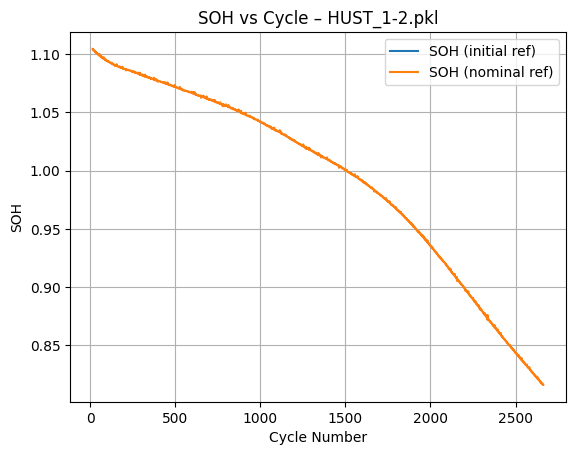

In [ ]:
import matplotlib.pyplot as plt

cell_id = df_hust["cell_file"].unique()[2]
df_one = df_hust[df_hust["cell_file"] == cell_id]

plt.plot(df_one["cycle_number"], df_one["SOH_initial"], label="SOH (initial ref)")
plt.plot(df_one["cycle_number"], df_one["SOH_nominal"], label="SOH (nominal ref)")
plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title(f"SOH vs Cycle – {cell_id}")
plt.legend()
plt.grid(True)
plt.show()


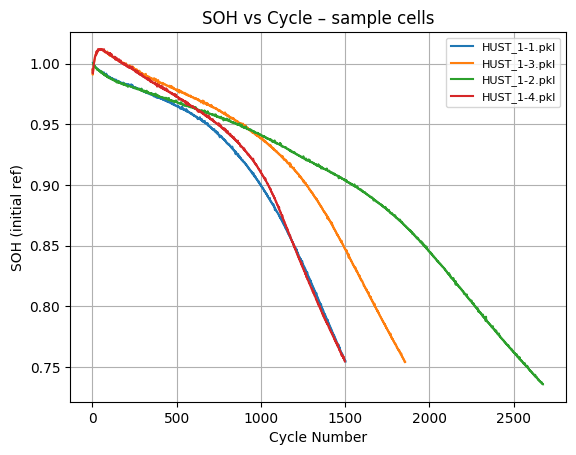

In [ ]:
for cell_id in df_hust["cell_file"].unique()[:4]:
    df_one = df_hust[df_hust["cell_file"] == cell_id]
    plt.plot(df_one["cycle_number"], df_one["SOH_initial"], label=cell_id)

plt.xlabel("Cycle Number")
plt.ylabel("SOH (initial ref)")
plt.title("SOH vs Cycle – sample cells")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


Correlation matrix:
              cycle_number  Qd_Ah  SOH_nominal  SOH_initial
cycle_number         1.000 -0.886       -0.886       -0.913
Qd_Ah               -0.886  1.000        1.000        0.991
SOH_nominal         -0.886  1.000        1.000        0.991
SOH_initial         -0.913  0.991        0.991        1.000


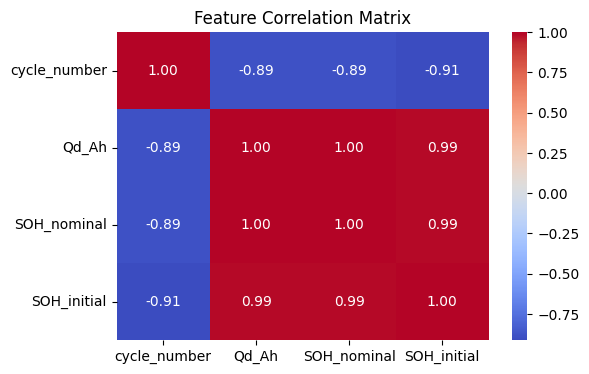

In [ ]:
import seaborn as sns

# keep only numeric columns for correlation
numeric_cols = ["cycle_number", "Qd_Ah", "SOH_nominal", "SOH_initial"]
corr = df_hust[numeric_cols].corr()

print("Correlation matrix:")
print(corr.round(3))

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

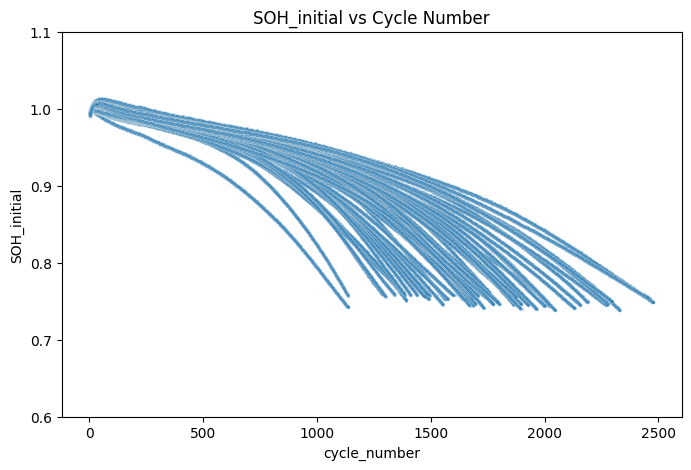

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_hust, x="cycle_number", y="SOH_initial", s=6, alpha=0.3)
plt.ylim(0.6, 1.1)
plt.title("SOH_initial vs Cycle Number")
plt.show()

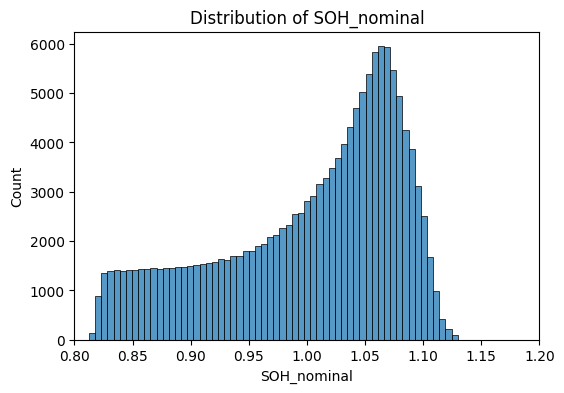

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_hust["SOH_nominal"].dropna(), bins=60)
plt.xlim(0.8, 1.2)
plt.title("Distribution of SOH_nominal")
plt.show()